<a target="_blank" href="https://colab.research.google.com/github/bmalcover/AppOC/blob/main/docs/notebooks/03_Series/02_Xarxes_Recurrents.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Recurrent Neural Networks (RNN)

## Limitations of MLP with Sequential Data

The MLPs we saw in block 2 treat each sample independently: they have no memory of previous inputs. This is appropriate when samples are unrelated to each other, but in a time series the order and temporal context are essential for making good predictions.

As discussed earlier, the window has a fixed size and the model cannot learn dependencies longer than the defined window. Moreover, it treats all values in the window symmetrically, without considering that more recent values tend to be more relevant.

## RNN Overview

A recurrent neural network (RNN) solves this problem by introducing the concept of a **hidden state** $h_t$: a vector that acts as memory and is passed from one time step to the next. At each step $t$, the network combines the current input $x_t$ with the previous hidden state $h_{t-1}$ to produce a new output and update the hidden state.

![RNN](../../_static/03/RNN-unrolled.png "RNN Desplegada")

## Types of Problems Solvable with RNNs

One of the strengths of recurrent networks is their flexibility in handling different input/output configurations:

- **One-to-one:** a single input produces a single output. Equivalent to a standard MLP, no recurrence is used.

- **One-to-many:** a single input produces a sequence of outputs. Example: generating a text description from an image.

- **Many-to-one:** a sequence of inputs produces a single output. Example: sentiment classification of a text, or predicting the next value in a time series from a window of past values.

- **Many-to-many (equal length):** a sequence of inputs produces a sequence of outputs of the same length. Example: part-of-speech tagging in NLP.

- **Many-to-many (different length):** a sequence of inputs produces a sequence of outputs of different length. Example: machine translation. This configuration is also known as **sequence-to-sequence (seq2seq)**.

In this course we will focus on the **many-to-one** configuration, which is the most common in time series forecasting: the model receives a window of past values and predicts the next value.

## RNN Architecture

Its formulation is as follows:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b),$$

$$\hat{y}_t = W_y \cdot h_t + b_y,$$

where $W_h$, $W_x$, and $W_y$ are the weight matrices and $b$ the biases. The weights are shared across all time steps, which allows the network to generalise regardless of the sequence length.

![RNN interna](../../_static/03/RNN.png "RNN Interior")

### Backpropagation Through Time

Training an RNN follows the same principle as an MLP: forward pass, loss calculation, backward pass, and weight update. The difference here is that the backward pass propagates through the time steps, hence the name **Backpropagation Through Time (BPTT)**.

### Gradient Problem

The vanishing gradient is the main limitation of simple RNNs. During BPTT, gradients are successively multiplied across time steps. Since the values of the $\tanh$ function are bounded between $(-1, 1)$, successive multiplications cause the gradient to approach zero rapidly, preventing the network from learning long-term dependencies.

In practice, a simple RNN struggles to learn relationships between events separated by more than 10–20 time steps.

See the PowerPoint presentation for more details.



## Example with PyTorch

We continue using the **Air Passengers** dataset to compare the results with the ARIMA model from the previous section.


In [1]:
# Importacio de les llibreries necessaries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error


First, we will prepare the data to be fed into the network. Although it may seem counterintuitive, we still need to define a time window over which the network will operate. In our case, given our knowledge of the data, we will set it to 12; this can be considered as an additional hyperparameter of the method.

In [2]:
# Càrrega del dataset
data = sm.datasets.get_rdataset("AirPassengers", "datasets").data
data.columns = ['time', 'passengers']
data.index = pd.date_range(start='1949-01', periods=len(data), freq='ME')
series = data['passengers'].values.astype(float)

# Normalització entre 0 i 1
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()

# Divisió train/test seqüencial (80/20)
train_size = int(len(series_scaled) * 0.8)
train = series_scaled[:train_size]
test  = series_scaled[train_size:]

We will use a custom function to transform the time series into input-output pairs suitable for training the network. For each time step $t$, the function takes the previous `window_size` observations as input and the value at $t$ as the target.

In [3]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

WINDOW_SIZE = 12

X_train, y_train = create_sequences(train, WINDOW_SIZE)
X_test,  y_test  = create_sequences(np.concatenate([train[-WINDOW_SIZE:], test]),
                                    WINDOW_SIZE)

When we create the sequences using the `create_sequences` function, we obtain an array of shape `[batch, seq_len]`, i.e. 2D. However, the PyTorch module we will use (`nn.RNN`) expects three-dimensional tensors of shape `[batch, seq_len, features]`, where `features` is the number of input variables. Since in this example we work with a single variable (the number of passengers), `features=1`, but PyTorch requires this dimension to exist explicitly. We can use the `unsqueeze(-1)` function, which adds this dimension at the end, transforming `[batch, seq_len]` into `[batch, seq_len, 1]`. If we were working with multiple variables, such as temperature, salinity, and pressure simultaneously, this last dimension would be greater than 1 and `unsqueeze` would not be needed.

In [4]:
# Conversió a tensors (RNN espera shape: [batch, seq_len, features])
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
X_test  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)

To better understand how the data is structured after applying the sliding window, let's inspect the first two samples of the training set:

In [5]:
print(X_train.shape)
print(X_train[0,:,0])
print(X_train[1,:,0])

torch.Size([103, 12, 1])
tensor([0.0154, 0.0270, 0.0541, 0.0483, 0.0328, 0.0598, 0.0849, 0.0849, 0.0618,
        0.0290, 0.0000, 0.0270])
tensor([0.0270, 0.0541, 0.0483, 0.0328, 0.0598, 0.0849, 0.0849, 0.0618, 0.0290,
        0.0000, 0.0270, 0.0212])


Now we need to define the model. In this case we cannot use the `nn.Sequential` module, we need a more complex construction. Instead, we must define the network using object-oriented programming.

We will define a class, in this case `RNNModel`, which has two methods:

- `__init__`: here we define the components (layers) that our network will have. In this case, an `nn.RNN` module called `self.rnn` and a linear output layer called `self.fc`.
- `forward`: here we define how the layers defined in `__init__` are connected.

The `nn.RNN` module contains all the logic of a recurrent neural network. Its most relevant parameters are:

- `input_size`: number of input variables at each time step. In our example this is 1 (a single variable).
- `hidden_size`: dimension of the hidden state vector $h_t$. Controls the model's capacity to learn complex representations.
- `num_layers`: number of stacked RNN layers. A value of 1 is sufficient for most simple cases.
- `batch_first`: if `True`, the input tensor is expected with shape `[batch, seq_len, features]`. If `False` (default), the expected shape is `[seq_len, batch, features]`. It is recommended to use `batch_first=True` for consistency with the rest of PyTorch.
- `nonlinearity`: activation function of the hidden state. The default is `'tanh'`, but `'relu'` is also accepted.

In [6]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # agafem l'últim pas temporal i el processam per una capa tipus MLP
        return out.squeeze()



Now we will create a model that has a 32-dimensional hidden state and later, without doing any training, we will make a prediction to see the result:

In [7]:
model = RNNModel(hidden_size=32)
out = model(X_train)
print(out.shape)

torch.Size([103])


The training is very similar to what we already know, here we will hardly notice any changes:

In [8]:
criterion = nn.MSELoss() # En aquest cas la funció de pèrdua és de regressió
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 1000
for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

Epoch 50/1000 - Loss: 0.014425
Epoch 100/1000 - Loss: 0.005034
Epoch 150/1000 - Loss: 0.004174
Epoch 200/1000 - Loss: 0.003429
Epoch 250/1000 - Loss: 0.002825
Epoch 300/1000 - Loss: 0.002546
Epoch 350/1000 - Loss: 0.002256
Epoch 400/1000 - Loss: 0.002571
Epoch 450/1000 - Loss: 0.002035
Epoch 500/1000 - Loss: 0.001877
Epoch 550/1000 - Loss: 0.005245
Epoch 600/1000 - Loss: 0.001848
Epoch 650/1000 - Loss: 0.001739
Epoch 700/1000 - Loss: 0.001648
Epoch 750/1000 - Loss: 0.001557
Epoch 800/1000 - Loss: 0.001455
Epoch 850/1000 - Loss: 0.001642
Epoch 900/1000 - Loss: 0.001570
Epoch 950/1000 - Loss: 0.001511
Epoch 1000/1000 - Loss: 0.001447


We will separate the evaluation to simplify the code blocks. In this case we will calculate the three metrics and show the network prediction graphically:

MAE:  28.96
RMSE: 37.22
MAPE: 6.35%


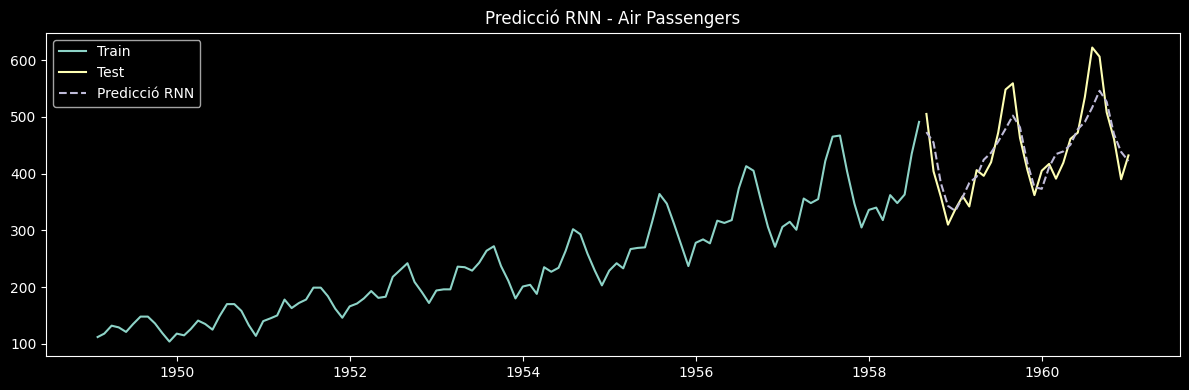

In [9]:
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_test).numpy()

# Desnormalització
predictions = scaler.inverse_transform(predictions_scaled.reshape(-1, 1))
y_test_real = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

mae  = mean_absolute_error(y_test_real, predictions)
rmse = np.sqrt(np.mean((y_test_real - predictions) ** 2))
mape = np.mean(np.abs((y_test_real - predictions) / y_test_real)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Visualització
test_index = data.index[train_size:]
plt.figure(figsize=(12, 4))
plt.plot(data.index[:train_size], series[:train_size], label='Train')
plt.plot(test_index, y_test_real, label='Test')
plt.plot(test_index, predictions, label='Predicció RNN', linestyle='--')
plt.legend()
plt.title('Predicció RNN - Air Passengers')
plt.tight_layout()
plt.show()

Although the RNN improves upon ARIMA, it still struggles to capture long-term seasonality due to the vanishing gradient problem. In the next section we will see how the LSTM solves this limitation.

## Exercise

Download a monthly sea surface temperature (SST) time series for the Mediterranean Sea from [surftemp.net](https://surftemp.net/timeseries/index.html) in CSV format. Choose a geographic area of your choice.

Once the data is loaded:

- Visualise the series and identify the trend and seasonality.
- Prepare the data using a sliding window and sequential train/test split.
- Train an RNN with PyTorch to predict the SST of the following month.
- Evaluate the model with MAE, RMSE, and MAPE and visualise the predictions.


[Sample data](link)